# Cell 0: Kiểm tra môi trường phần cứng (GPU)

In [24]:
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA Available: True
GPU: Tesla T4


# Cell 1: Import tất cả các thư viện cần thiết cho dự án

In [25]:
import os
import glob
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Cell 2: Kiểm tra cấu trúc và đường dẫn dataset trong môi trường Kaggle

In [26]:
input_dir = "/kaggle/input"
dataset_paths = glob.glob(os.path.join(input_dir, "**", "*"), recursive=True)
print(f"Total items found in input: {len(dataset_paths)}")

directories = [p for p in dataset_paths if os.path.isdir(p)]
print("\nAvailable main directories:")
for d in directories:
    if len(os.path.dirname(d)) == len(input_dir):
        print(d)

Total items found in input: 50172

Available main directories:
/kaggle/input/datasets


# Cell 3: Thực hiện EDA (Kiểm tra số lớp, tổng số ảnh, phân bố và kích thước ảnh)

In [27]:
root_dir = "/kaggle/input/datasets"
extensions = ("*.jpg", "*.jpeg", "*.png", "*.BMP", "*.JPG", "*.JPEG", "*.PNG")
found_files = []

for ext in extensions:
    found_files.extend(glob.glob(os.path.join(root_dir, "**", ext), recursive=True))

print(f"Tổng số file ảnh tìm thấy: {len(found_files)}")
if found_files:
    print("\nVí dụ 5 đường dẫn file ảnh đầu tiên:")
    for f in found_files[:5]:
        print(f)

Tổng số file ảnh tìm thấy: 50154

Ví dụ 5 đường dẫn file ảnh đầu tiên:
/kaggle/input/datasets/techsash/waste-classification-data/DATASET/TEST/R/R_10683.jpg
/kaggle/input/datasets/techsash/waste-classification-data/DATASET/TEST/R/R_10736.jpg
/kaggle/input/datasets/techsash/waste-classification-data/DATASET/TEST/R/R_10489.jpg
/kaggle/input/datasets/techsash/waste-classification-data/DATASET/TEST/R/R_10512.jpg
/kaggle/input/datasets/techsash/waste-classification-data/DATASET/TEST/R/R_10975.jpg


Số lượng lớp (classes): 2 -> ['O', 'R']
Tổng số lượng ảnh hợp lệ: 25077

Số lượng ảnh cụ thể từng lớp:
label
O    13966
R    11111
Name: count, dtype: int64


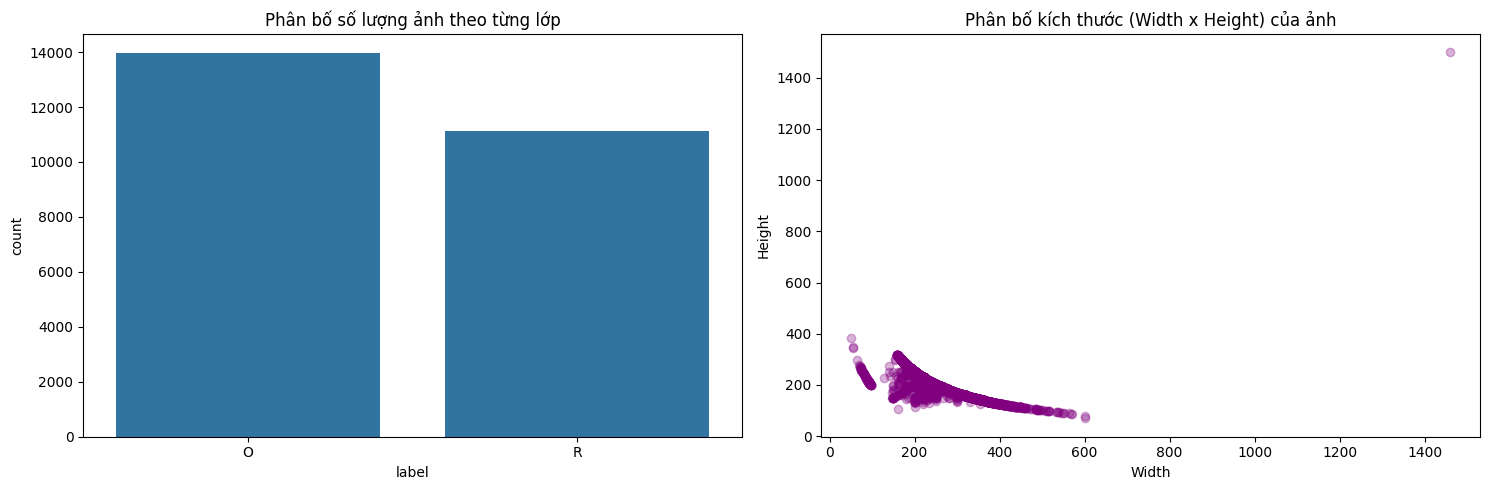

In [28]:
base_path = "/kaggle/input/datasets/techsash/waste-classification-data/DATASET"
all_img_paths = []

for root, _, files in os.walk(base_path):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            all_img_paths.append(os.path.join(root, f))

data = []
img_sizes = []

for p in all_img_paths:
    parts = p.split(os.sep)
    cls = parts[-2]
    try:
        with Image.open(p) as img:
            w, h = img.size
            img_sizes.append((w, h))
            data.append({"path": p, "label": cls})
    except:
        continue

df = pd.DataFrame(data)
sizes_df = pd.DataFrame(img_sizes, columns=["Width", "Height"])
classes = sorted(df["label"].unique())

print(f"Số lượng lớp (classes): {len(classes)} -> {classes}")
print(f"Tổng số lượng ảnh hợp lệ: {len(df)}")
print("\nSố lượng ảnh cụ thể từng lớp:")
print(df["label"].value_counts())

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x="label", order=classes)
plt.title("Phân bố số lượng ảnh theo từng lớp")

plt.subplot(1, 2, 2)
plt.scatter(sizes_df["Width"], sizes_df["Height"], alpha=0.3, c="purple")
plt.title("Phân bố kích thước (Width x Height) của ảnh")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()
plt.show()

# Cell 4: Tìm và loại bỏ các ảnh trùng lặp bằng thuật toán băm MD5

In [29]:
def calculate_md5(filepath):
    hasher = hashlib.md5()
    with open(filepath, 'rb') as f:
        buf = f.read(65536)
        while len(buf) > 0:
            hasher.update(buf)
            buf = f.read(65536)
    return hasher.hexdigest()

df['md5'] = df['path'].apply(calculate_md5)
df_clean = df.drop_duplicates(subset=['md5'], keep='first').copy()

print(f"Số lượng ảnh ban đầu: {len(df)}")
print(f"Số lượng ảnh sau khi xóa trùng lặp: {len(df_clean)}")
print(f"Số lượng ảnh bị xóa: {len(df) - len(df_clean)}")

Số lượng ảnh ban đầu: 25077
Số lượng ảnh sau khi xóa trùng lặp: 24751
Số lượng ảnh bị xóa: 326


# Cell 5: Phân chia tập dữ liệu (80% Train, 10% Val, 10% Test) và trực quan hóa

Số lượng ảnh sau khi chia tập:
 - Tập Train: 19800 ảnh
 - Tập Validation: 2475 ảnh
 - Tập Test: 2476 ảnh


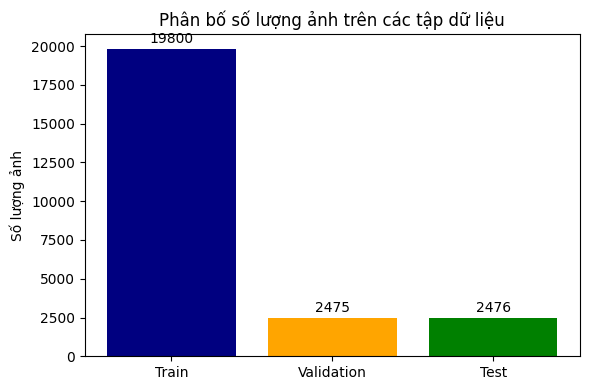

In [30]:
train_df, temp_df = train_test_split(df_clean, test_size=0.20, stratify=df_clean['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

split_counts = {
    'Train': len(train_df),
    'Validation': len(val_df),
    'Test': len(test_df)
}

print("Số lượng ảnh sau khi chia tập:")
for stage, count in split_counts.items():
    print(f" - Tập {stage}: {count} ảnh")

plt.figure(figsize=(6, 4))
bars = plt.bar(split_counts.keys(), split_counts.values(), color=['navy', 'orange', 'green'])
plt.title("Phân bố số lượng ảnh trên các tập dữ liệu")
plt.ylabel("Số lượng ảnh")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 200, f'{yval}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Cell 6: Định nghĩa PyTorch Dataset, thực hiện Resize và Chuẩn hóa dữ liệu

In [31]:
class GarbageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        self.labels_map = {label: idx for idx, label in enumerate(sorted(dataframe['label'].unique()))}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label_str = self.df.iloc[idx]['label']
        label = self.labels_map[label_str]
        
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
            
        return img, label

img_size = 128
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

base_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Cell 7: Cấu hình Data Augmentation tối ưu cho tập Train

In [32]:
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_dataset = GarbageDataset(train_df, transform=train_transform)
val_dataset = GarbageDataset(val_df, transform=base_transform)
test_dataset = GarbageDataset(test_df, transform=base_transform)

# Cell 8: Thiết lập siêu tham số và khởi tạo DataLoader cho các tập dữ liệu

In [33]:
batch_size = 64
learning_rate = 0.001
epochs = 15

num_workers = os.cpu_count()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"Device đang sử dụng: {device}")
print(f"Tổng số lượng Batch trong Train Loader: {len(train_loader)}")

Device đang sử dụng: cuda
Tổng số lượng Batch trong Train Loader: 310


# Cell 9: Định nghĩa kiến trúc mô hình CNN từ đầu (Không dùng Pretrained)

In [34]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class AdvancedGarbageCNN(nn.Module):
    def __init__(self):
        super(AdvancedGarbageCNN, self).__init__()
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.layer1 = ResidualBlock(32, 64, stride=2)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        self.layer4 = ResidualBlock(256, 512, stride=2)
        
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.init_conv(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# Khởi tạo mô hình sạch
model = AdvancedGarbageCNN().to(device)
print("-> cấu trúc ResNet nguyên bản ổn định!")

-> cấu trúc ResNet nguyên bản ổn định!


# Cell 9.1: In cấu trúc chi tiết và tổng số lượng tham số của mô hình

In [35]:
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

img_size = 128 

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(degrees=15),       
    transforms.RandomHorizontalFlip(p=0.5),      
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class GarbageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_mapping = {'O': 0, 'R': 1}
        
        possible_path_cols = [col for col in self.df.columns if 'path' in col.lower() or 'img' in col.lower() or 'file' in col.lower()]
        self.path_column = possible_path_cols[0] if len(possible_path_cols) > 0 else self.df.columns[0]
            
        possible_label_cols = [col for col in self.df.columns if 'label' in col.lower() or 'class' in col.lower() or 'target' in col.lower()]
        self.label_column = possible_label_cols[0] if len(possible_label_cols) > 0 else self.df.columns[1]

    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img_path = self.df.loc[idx, self.path_column]
        label_str = self.df.loc[idx, self.label_column]
        label = self.label_mapping[label_str]
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

train_dataset = GarbageDataset(train_df, transform=train_transform)
val_dataset = GarbageDataset(val_df, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print("-> Cell 9.1: Đã đưa cấu hình DataLoader về trạng thái cân bằng gốc!")

-> Cell 9.1: Đã đưa cấu hình DataLoader về trạng thái cân bằng gốc!


# Cell 10: Thực hiện vòng lặp huấn luyện (Training Loop) và lưu Checkpoint tốt nhất

In [36]:
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Thiết bị tăng tốc: {torch.cuda.get_device_name(0)}")

CUDA Available: True
Thiết bị tăng tốc: Tesla T4


In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
import glob

# =====================================================================
# TỰ ĐỘNG XÓA SẠCH TẤT CẢ FILE .PTH CŨ TRÁNH XUNG ĐỘT KHI DÁN ĐÈ
# =====================================================================
old_weights = glob.glob('*.pth')
if old_weights:
    print("=== TIẾN HÀNH XÓA SẠCH LỊCH SỬ HUẤN LUYỆN CŨ ===")
    for f in old_weights:
        try: os.remove(f)
        except: pass
    print("-> Thư mục làm việc hoàn toàn trống trải, sẵn sàng nạp đợt chạy an toàn!\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================================
# CẤU HÌNH SIÊU THAM SỐ
# =====================================================================
epochs        = 50
patience      = 7       # Early Stopping: dừng nếu không cải thiện sau 7 epoch
min_delta     = 1e-4    # Ngưỡng tối thiểu để tính là có tiến bộ

criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)

# Giữ nguyên lr=2e-04, thêm warmup để LR tăng dần từ nhỏ thay vì nhảy thẳng
# vào 2e-04 ngay epoch đầu — tránh dao động mạnh ở giai đoạn đầu
optimizer  = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-3)

# CosineAnnealingLR với eta_min — LR không về 0 mà dừng ở 1e-6
# Giúp cuối quá trình không dao động do bước cập nhật quá nhỏ hoặc quá lớn
scheduler  = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs, eta_min=1e-6
)

history        = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss  = float('inf')
no_improve     = 0

print("=== BẮT ĐẦU HUẤN LUYỆN (50 EPOCHS — EARLY STOPPING patience=7) ===\n")

for epoch in range(epochs):
    # ------------------------------------------------------------------
    # WARMUP: 3 epoch đầu tăng LR từ 1e-6 lên 2e-4 dần dần
    # Tránh bước nhảy LR lớn ngay từ đầu gây dao động Val Loss
    # ------------------------------------------------------------------
    if epoch < 3:
        warmup_lr = 2e-4 * (epoch + 1) / 3
        for pg in optimizer.param_groups:
            pg['lr'] = warmup_lr

    # --- TRAIN ---
    model.train()
    train_loss, train_corrects = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping — cắt gradient quá lớn, tránh bước nhảy đột ngột
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss     += loss.item() * inputs.size(0)
        _, preds        = torch.max(outputs, 1)
        train_corrects += torch.sum(preds == labels.data)

    # --- VALIDATION ---
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            val_loss       += loss.item() * inputs.size(0)
            _, preds        = torch.max(outputs, 1)
            val_corrects   += torch.sum(preds == labels.data)

    # Chỉ gọi scheduler sau warmup
    if epoch >= 3:
        scheduler.step()

    epoch_train_loss = train_loss      / len(train_loader.dataset)
    epoch_train_acc  = train_corrects.double().item() / len(train_loader.dataset)
    epoch_val_loss   = val_loss        / len(val_loader.dataset)
    epoch_val_acc    = val_corrects.double().item()   / len(val_loader.dataset)

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.2f}% | "
          f"LR: {current_lr:.2e}")

    # --- CHECKPOINT & EARLY STOPPING ---
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        no_improve    = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print("  -> Đã lưu best_model.pth (val_loss cải thiện)")
    else:
        no_improve += 1
        print(f"  -> Không cải thiện ({no_improve}/{patience})")
        if no_improve >= patience:
            print(f"\n=== EARLY STOPPING tại Epoch {epoch+1} "
                  f"— không cải thiện sau {patience} epoch liên tiếp ===")
            break

print(f"\n=== HUẤN LUYỆN HOÀN TẤT! — Best Val Loss: {best_val_loss:.4f} ===")

=== TIẾN HÀNH XÓA SẠCH LỊCH SỬ HUẤN LUYỆN CŨ ===
-> Thư mục làm việc hoàn toàn trống trải, sẵn sàng nạp đợt chạy an toàn!

=== BẮT ĐẦU HUẤN LUYỆN (50 EPOCHS — EARLY STOPPING patience=7) ===

Epoch 01/50 | Train Loss: 0.4850 Acc: 81.63% | Val Loss: 0.4514 Acc: 84.69% | LR: 6.67e-05
  -> Đã lưu best_model.pth (val_loss cải thiện)
Epoch 02/50 | Train Loss: 0.4440 Acc: 84.42% | Val Loss: 0.4260 Acc: 85.66% | LR: 1.33e-04
  -> Đã lưu best_model.pth (val_loss cải thiện)
Epoch 03/50 | Train Loss: 0.4276 Acc: 85.52% | Val Loss: 0.4319 Acc: 86.63% | LR: 2.00e-04
  -> Không cải thiện (1/7)
Epoch 04/50 | Train Loss: 0.4105 Acc: 87.06% | Val Loss: 0.4113 Acc: 87.19% | LR: 2.00e-04
  -> Đã lưu best_model.pth (val_loss cải thiện)
Epoch 05/50 | Train Loss: 0.4011 Acc: 87.49% | Val Loss: 0.4050 Acc: 87.64% | LR: 1.99e-04
  -> Đã lưu best_model.pth (val_loss cải thiện)
Epoch 06/50 | Train Loss: 0.3867 Acc: 88.64% | Val Loss: 0.3966 Acc: 87.35% | LR: 1.98e-04
  -> Đã lưu best_model.pth (val_loss cải thi

# Cell 11: Vẽ biểu đồ lịch sử huấn luyện (Train/Val Loss và Accuracy)

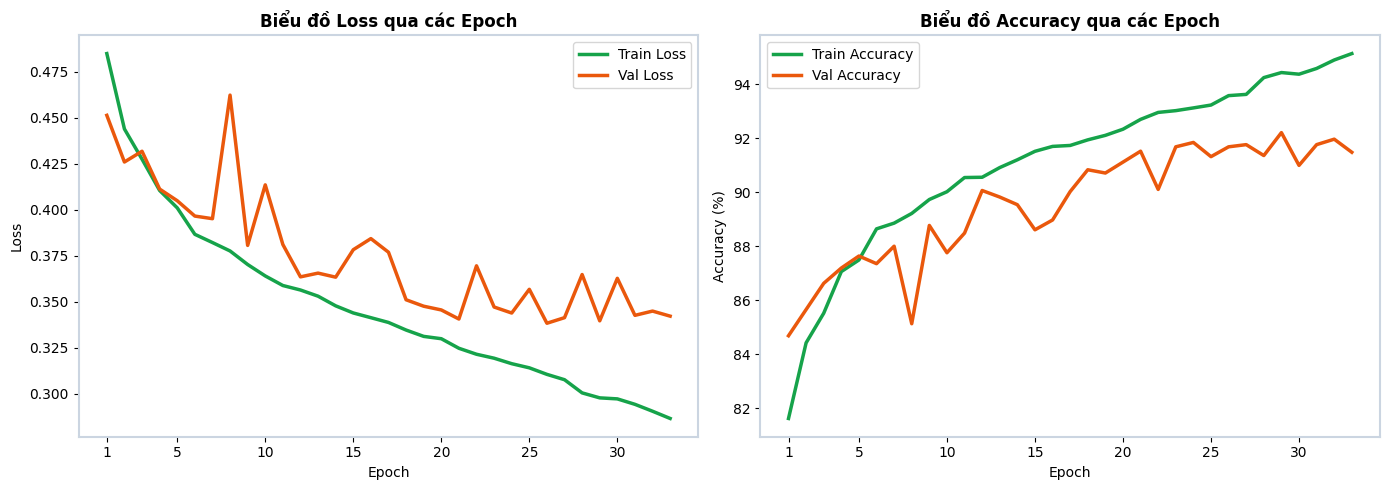

In [44]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = list(range(1, len(history['train_loss']) + 1))
tick_positions = [e for e in epochs_range if e % 5 == 0 or e == 1]

# Loss
ax1.plot(epochs_range, history['train_loss'], color='#16a34a', linewidth=2.5, label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   color='#ea580c', linewidth=2.5, label='Val Loss')
ax1.set_title('Biểu đồ Loss qua các Epoch', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_xticks(tick_positions)
ax1.legend()
ax1.set_facecolor('white')
ax1.grid(False)
for sp in ax1.spines.values():
    sp.set_visible(True)
    sp.set_linewidth(1.5)
    sp.set_color('#CBD5E1')

# Accuracy
train_acc = [a * 100 for a in history['train_acc']]
val_acc   = [a * 100 for a in history['val_acc']]
ax2.plot(epochs_range, train_acc, color='#16a34a', linewidth=2.5, label='Train Accuracy')
ax2.plot(epochs_range, val_acc,   color='#ea580c', linewidth=2.5, label='Val Accuracy')
ax2.set_title('Biểu đồ Accuracy qua các Epoch', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(tick_positions)
ax2.legend()
ax2.set_facecolor('white')
ax2.grid(False)
for sp in ax2.spines.values():
    sp.set_visible(True)
    sp.set_linewidth(1.5)
    sp.set_color('#CBD5E1')

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

# Cell 12: Đánh giá hiệu năng trên tập Test (Confusion Matrix, Classification Report)

-> Đã nạp thành công tệp trọng số nguyên bản để tiến hành chấm điểm!

BÁO CÁO ĐÁNH GIÁ CHẤT LƯỢNG MÔ HÌNH NGUYÊN BẢN:
                precision    recall  f1-score   support

   Organic (O)       0.92      0.93      0.92      1365
Recyclable (R)       0.91      0.90      0.91      1110

      accuracy                           0.92      2475
     macro avg       0.92      0.92      0.92      2475
  weighted avg       0.92      0.92      0.92      2475



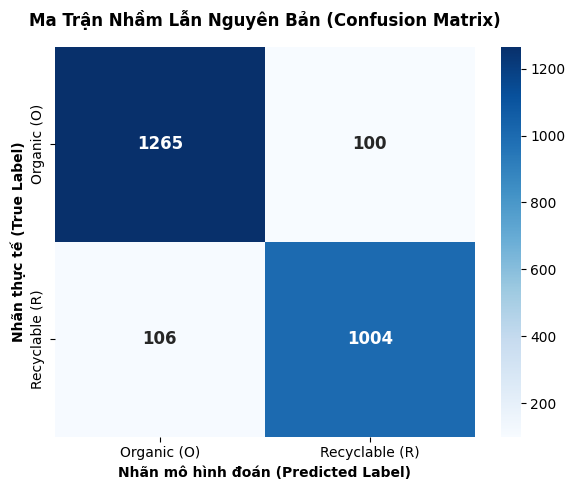

In [39]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix

weight_path = 'best_model.pth'
if os.path.exists(weight_path):
    model.load_state_dict(torch.load(weight_path, map_location=device))
    print("-> Đã nạp thành công tệp trọng số nguyên bản để tiến hành chấm điểm!")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\n" + "="*60)
print("BÁO CÁO ĐÁNH GIÁ CHẤT LƯỢNG MÔ HÌNH NGUYÊN BẢN:")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['Organic (O)', 'Recyclable (R)']))
print("="*60)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Organic (O)', 'Recyclable (R)'], 
            yticklabels=['Organic (O)', 'Recyclable (R)'],
            annot_kws={"size": 12, "weight": "bold"})
plt.title('Ma Trận Nhầm Lẫn Nguyên Bản (Confusion Matrix)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Nhãn thực tế (True Label)', fontsize=10, fontweight='bold')
plt.xlabel('Nhãn mô hình đoán (Predicted Label)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Cell 13: Xuất và lưu trữ vĩnh viễn mô hình cấu trúc ResNet tối ưu nhất từ đầu

In [40]:
import os
import time
from IPython.display import FileLink

# Đường dẫn đến file trọng số tốt nhất đã được lưu từ Cell 10 nguyên bản
final_model_name = 'best_model.pth'
final_model_path = f'/kaggle/working/{final_model_name}'

print("="*60)
print("=== HỆ THỐNG KIỂM TRA VÀ XUẤT FILE TRỌNG SỐ TỐI ƯU ENSEMBLE ===")
print("="*60)

# Chờ 1 giây để đảm bảo hệ điều hành hoàn tất việc ghi file từ RAM xuống ổ cứng
time.sleep(1)

if os.path.exists(final_model_path):
    # Tính toán kích thước file vật lý
    file_size_bytes = os.path.getsize(final_model_path)
    file_size_mb = file_size_bytes / (1024 * 1024)
    
    print(f"✅ TRẠNG THÁI: Thành công! Tìm thấy file trọng số.")
    print(f"📂 Tên file lưu trữ: {final_model_name}")
    print(f"💾 Kích thước tệp tin: {file_size_mb:.2f} MB")
    print(f"📍 Vị trí vật lý: {final_model_path}")
    print("-"*60)
    print("🚀 ĐƯỜNG DẪN TẢI XUỐNG TRỰC TIẾP (CLICK VÀO LINK DƯỚI ĐÂY):")
    
    # Tạo đường link tải nhanh trực tiếp trên giao diện Notebook
    display(FileLink(final_model_name))
    
    print("-"*60)
    print("💡 Hướng dẫn tiếp theo: Hãy tải file này về máy local, dán đè vào")
    print("   thư mục backend FastAPI của bạn để chạy test giao diện App nhé!")
else:
    print(f"❌ TRẠNG THÁI: Thất bại! Không tìm thấy tệp '{final_model_name}' trong thư mục hiện tại.")
    print("💡 Lời khuyên: Hãy kiểm tra lại xem Cell 10 đã chạy xong hoàn toàn chưa,")
    print("   hoặc có bị báo lỗi phân bổ bộ nhớ GPU giữa chừng hay không.")

print("="*60)

=== HỆ THỐNG KIỂM TRA VÀ XUẤT FILE TRỌNG SỐ TỐI ƯU ENSEMBLE ===
✅ TRẠNG THÁI: Thành công! Tìm thấy file trọng số.
📂 Tên file lưu trữ: best_model.pth
💾 Kích thước tệp tin: 18.67 MB
📍 Vị trí vật lý: /kaggle/working/best_model.pth
------------------------------------------------------------
🚀 ĐƯỜNG DẪN TẢI XUỐNG TRỰC TIẾP (CLICK VÀO LINK DƯỚI ĐÂY):


/kaggle/working/best_model.pth

------------------------------------------------------------
💡 Hướng dẫn tiếp theo: Hãy tải file này về máy local, dán đè vào
   thư mục backend FastAPI của bạn để chạy test giao diện App nhé!
